In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import gym
from main.alpaca import *
from main.dataset import *
from main.dataViz import *
import yaml
import torch

In [2]:
cfg_filename = 'configs/multistep-config.yml'
with open(cfg_filename,'r') as ymlfile:
    config = yaml.load(ymlfile, Loader=yaml.SafeLoader)

In [3]:
noise1 = 0.1
noise2 = 0.3
noise3 = 0.5
dataset1 = MultistepDataset(config, noise_var=noise1, rng=np.random.RandomState(1234))
dataset2 = MultistepDataset(config, noise_var=noise2, rng=np.random.RandomState(1234))
dataset3 = MultistepDataset(config, noise_var=noise3, rng=np.random.RandomState(1234))

## Default agent

In [4]:
steps = 5000
config1 = config.copy()
config1["sigma_eps"] = noise1
agent1 = ALPaCA(config1)
train_log1 = agent1.train_step(dataset1, num_train_updates=steps)
agent1.eval()  # ready for evaluation/plotting

iter      0  loss: 1.041916  RMSE_1step: 0.596734  MPV_1step: 17.077675
iter     50  loss: -0.107644  RMSE_1step: 0.405896  MPV_1step: 0.196668
iter    100  loss: 0.204952  RMSE_1step: 0.330332  MPV_1step: 0.286193
iter    150  loss: 0.012738  RMSE_1step: 0.349092  MPV_1step: 0.242940
iter    200  loss: -0.035004  RMSE_1step: 0.505604  MPV_1step: 0.495526
iter    250  loss: -0.079711  RMSE_1step: 0.341762  MPV_1step: 0.385303
iter    300  loss: -0.189115  RMSE_1step: 0.394557  MPV_1step: 0.310846
iter    350  loss: -0.341741  RMSE_1step: 0.462108  MPV_1step: 0.230436
iter    400  loss: -0.151350  RMSE_1step: 0.316410  MPV_1step: 0.269890
iter    450  loss: -0.149841  RMSE_1step: 0.447606  MPV_1step: 0.316385
iter    500  loss: -0.384108  RMSE_1step: 0.339055  MPV_1step: 0.203839
iter    550  loss: -0.329818  RMSE_1step: 0.484757  MPV_1step: 0.261349
iter    600  loss: -0.380443  RMSE_1step: 0.430686  MPV_1step: 0.260785
iter    650  loss: -0.391726  RMSE_1step: 0.396586  MPV_1step: 0.3

ALPaCA(
  (phi_net): MLP(
    (act): Tanh()
    (layers): ModuleList(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
    )
  )
)

In [5]:
config2 = config.copy()
config2["sigma_eps"] = noise2
agent2 = ALPaCA(config2)
train_log2 = agent2.train_step(dataset2, num_train_updates=steps)
agent2.eval()

iter      0  loss: 1.434237  RMSE_1step: 0.715740  MPV_1step: 998.181274
iter     50  loss: 0.586438  RMSE_1step: 0.612861  MPV_1step: 0.887713
iter    100  loss: 0.631164  RMSE_1step: 0.528331  MPV_1step: 0.426103
iter    150  loss: 0.436464  RMSE_1step: 0.512208  MPV_1step: 0.512303
iter    200  loss: 0.442234  RMSE_1step: 0.645106  MPV_1step: 0.510551
iter    250  loss: 0.352019  RMSE_1step: 0.387781  MPV_1step: 0.398892
iter    300  loss: 0.434791  RMSE_1step: 0.630778  MPV_1step: 0.574267
iter    350  loss: 0.294414  RMSE_1step: 0.613789  MPV_1step: 0.458822
iter    400  loss: 0.325849  RMSE_1step: 0.527164  MPV_1step: 0.493375
iter    450  loss: 0.444614  RMSE_1step: 0.608218  MPV_1step: 0.497016
iter    500  loss: 0.314564  RMSE_1step: 0.486645  MPV_1step: 0.439747
iter    550  loss: 0.369797  RMSE_1step: 0.707812  MPV_1step: 0.535816
iter    600  loss: 0.314582  RMSE_1step: 0.599632  MPV_1step: 0.495983
iter    650  loss: 0.338892  RMSE_1step: 0.642874  MPV_1step: 0.510906
iter

ALPaCA(
  (phi_net): MLP(
    (act): Tanh()
    (layers): ModuleList(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
    )
  )
)

In [6]:
config3 = config.copy()
config3["sigma_eps"] = noise3
agent3 = ALPaCA(config3)
train_log3 = agent3.train_step(dataset3, num_train_updates=steps)
agent3.eval()

iter      0  loss: 0.949800  RMSE_1step: 0.803359  MPV_1step: 1.121123
iter     50  loss: 0.784927  RMSE_1step: 0.815333  MPV_1step: 1.057899
iter    100  loss: 0.863167  RMSE_1step: 0.591334  MPV_1step: 0.699354
iter    150  loss: 0.799409  RMSE_1step: 0.697846  MPV_1step: 0.827089
iter    200  loss: 0.754333  RMSE_1step: 0.692001  MPV_1step: 0.722883
iter    250  loss: 0.716170  RMSE_1step: 0.599166  MPV_1step: 0.630493
iter    300  loss: 0.751380  RMSE_1step: 0.736225  MPV_1step: 0.704239
iter    350  loss: 0.636734  RMSE_1step: 0.771474  MPV_1step: 0.650858
iter    400  loss: 0.693424  RMSE_1step: 0.579622  MPV_1step: 0.708726
iter    450  loss: 0.762357  RMSE_1step: 0.798148  MPV_1step: 0.745709
iter    500  loss: 0.752995  RMSE_1step: 0.550607  MPV_1step: 0.720357
iter    550  loss: 0.750649  RMSE_1step: 0.821861  MPV_1step: 0.789336
iter    600  loss: 0.721508  RMSE_1step: 0.686537  MPV_1step: 0.720729
iter    650  loss: 0.667721  RMSE_1step: 0.726699  MPV_1step: 0.724712
iter  

ALPaCA(
  (phi_net): MLP(
    (act): Tanh()
    (layers): ModuleList(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
    )
  )
)

# Visualize all agents

In [7]:
N_test = 50
test_horz = 30
dataset1 = MultistepDataset(config, noise_var=noise1, rng=np.random.RandomState(4321))
dataset2 = MultistepDataset(config, noise_var=noise2, rng=np.random.RandomState(4321))
dataset3 = MultistepDataset(config, noise_var=noise3, rng=np.random.RandomState(4321))
X_test1, Y_test1, step_mat_test = dataset1.sample(N_test, test_horz, return_lists=True)
X_test2, Y_test2 = dataset2.sample(N_test, test_horz, return_lists=False)
X_test3, Y_test3 = dataset3.sample(N_test, test_horz, return_lists=False)

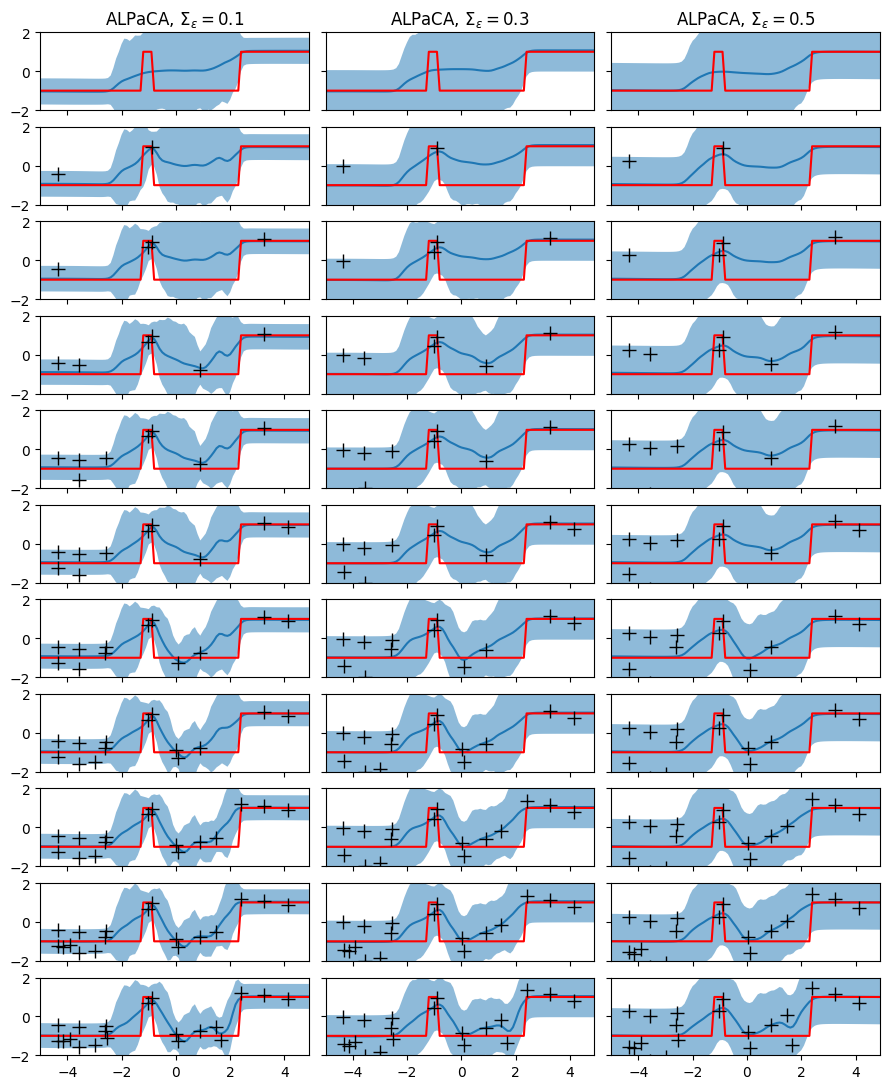

In [8]:
ind = 4
sample_size_list = [0,2,4,6,8,10,12,14,16,18,20]
plt.figure(figsize=(9,len(sample_size_list)*1))
for i,num_pts in enumerate(sample_size_list):
    X_update1 = X_test1[ind:(ind+1),:num_pts,:]
    Y_update1 = Y_test1[ind:(ind+1),:num_pts,:]
    
    X_update2 = X_test2[ind:(ind+1),:num_pts,:]
    Y_update2 = Y_test2[ind:(ind+1),:num_pts,:]
    
    X_update3 = X_test3[ind:(ind+1),:num_pts,:]
    Y_update3 = Y_test3[ind:(ind+1),:num_pts,:]
    
    title=None
    legend=False
    if i == 0:
        legend=True
        title=True

    ax1 = plt.subplot(len(sample_size_list),3,3*i+1)
    gen_multistep_fig(agent1, X_update1, Y_update1, step_mat_test[ind,:], label=None)
    if i == 0:
        plt.title(r'ALPaCA, ' + r'$\Sigma_\epsilon = 0.1$')
    if i < len(sample_size_list) - 1:
        plt.setp(ax1.get_xticklabels(), visible=False)
        
    ax2 = plt.subplot(len(sample_size_list),3,3*i+2, sharey=ax1)
    gen_multistep_fig(agent2, X_update2, Y_update2, step_mat_test[ind,:], label=None)
    plt.setp(ax2.get_yticklabels(), visible=False)
    if i == 0:
        plt.title(r'ALPaCA, ' + r'$\Sigma_\epsilon = 0.3$')
    if i < len(sample_size_list) - 1:
        plt.setp(ax2.get_xticklabels(), visible=False)
    
    
    ax3 = plt.subplot(len(sample_size_list),3,3*i+3, sharey=ax1)
    gen_multistep_fig(agent3, X_update3, Y_update3, step_mat_test[ind,:], label=None)
    plt.setp(ax3.get_yticklabels(), visible=False)
    if i == 0:
        plt.title(r'ALPaCA, ' + r'$\Sigma_\epsilon = 0.5$')
    if i < len(sample_size_list) - 1:
        plt.setp(ax3.get_xticklabels(), visible=False)

plt.tight_layout(w_pad=0.0,h_pad=0.2)
plt.savefig('figures/multistep_varying_noise.pdf')
plt.show()

In [9]:
# K,L = sess1.run([agent.K, agent.L])
# x_range = np.reshape( np.linspace(-5,5,100), (1,100,1) )
# phi = sess1.run( agent.phi, {agent.x: x_range} ) #agent.encode(sess,x_range)
# plot_sample_fns(x_range,phi,K,L,sess1.run(agent.SigEps),10)

In [10]:
# x_range = np.reshape( np.linspace(-5,5,100), (1,100,1) )
# gen_sin_bases_fig(agent, sess1, x_range, 32)